In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

touchpoints = pd.read_csv("Lumina Co CRM/touchpoints.csv")
campaigns = pd.read_csv("Lumina Co CRM/campaigns.csv")

touchpoints.head()

,touchpoint_id,customer_id,invoice_id,journey_id,campaign_name,timestamp,channel,position,n_touchpoints,click,converted,cost,is_last_before_conversion
0,0,12346,NaN,conv_541431,Summer_Sale,2025-07-27 22:03:12.473059457,email,2,4,1,0,0.0156,0
1,1,12346,NaN,conv_541431,Summer_Sale,2025-08-01 18:48:15.521925754,affiliate,3,4,1,0,0.0000,0
2,2,12346,541431.0,conv_541431,Summer_Sale,2025-08-08 19:43:30.750000041,retargeting,4,4,1,1,0.0128,1
3,3,12346,NaN,exp_3209,Back_to_School,2025-08-24 04:38:02.208965716,social,1,8,0,0,0.0000,0
4,4,12346,NaN,exp_3209,Back_to_School,2025-08-30 13:11:10.761750471,social,2,8,1,0,2.0420,0


In [2]:
print(touchpoints.shape, campaigns.shape)
print(touchpoints.dtypes)
print(campaigns.dtypes)
touchpoints["channel"].value_counts()

(1080897, 13) (6, 14)
touchpoint_id                  int64
customer_id                    int64
invoice_id                   float64
journey_id                       str
campaign_name                    str
timestamp                        str
channel                          str
position                       int64
n_touchpoints                  int64
click                          int64
converted                      int64
cost                         float64
is_last_before_conversion      int64
dtype: object
campaign_name          str
n_touchpoints        int64
n_clients            int64
n_clicks             int64
n_conversions        int64
total_cost         float64
revenue            float64
ctr                float64
conversion_rate    float64
cpa                float64
roas               float64
primary_channel        str
start_date             str
end_date               str
dtype: object


channel
display        316530
social         315763
retargeting    158102
email          150733
affiliate       54516
direct          43919
search_paid     41334
Name: count, dtype: int64

Avant de calculer quoi que ce soit, je regarde la structure des deux fichiers et la liste des canaux présents — je m'attends à retrouver les 6 canaux mentionnés dans l'énoncé (email, social organique/payant, SEO/SEA, affiliation, display, retargeting). Je vérifie aussi les types de colonnes, en particulier les dates qui seront probablement à convertir comme au Jour 1.

ETAPE I

In [17]:
transactions = pd.read_csv("Lumina Co CRM/transactions.csv")
customers = pd.read_csv("Lumina Co CRM/customers.csv")

transactions["invoice_date"] = pd.to_datetime(transactions["invoice_date"])
transactions["line_total"] = transactions["quantity"] * transactions["unit_price"]
customers["first_purchase"] = pd.to_datetime(customers["first_purchase"])

touchpoints["invoice_id"] = touchpoints["invoice_id"].astype(str).str.replace(r"\.0$", "", regex=True)
transactions["invoice_id"] = transactions["invoice_id"].astype(str)

touchpoints_with_date = touchpoints.merge(
    transactions[["invoice_id", "invoice_date"]], 
    on="invoice_id", how="left"
)
touchpoints_with_date = touchpoints_with_date.merge(
    customers[["customer_id", "first_purchase"]], on="customer_id", how="left"
)

touchpoints_with_date["is_primo_achat"] = (
    touchpoints_with_date["invoice_date"] == touchpoints_with_date["first_purchase"]
)
print(touchpoints_with_date["is_primo_achat"].value_counts())

is_primo_achat
False    1522542
True       35476
Name: count, dtype: int64


J'ai retiré customer_id de la liste des colonnes récupérées depuis transactions — touchpoints.csv l'avait déjà nativement, donc mon premier merge créait un conflit de nom (customer_id_x/customer_id_y) qui faisait disparaître la colonne customer_id toute simple dont j'avais besoin pour le second merge.

In [18]:
# Le coût est directement disponible par touchpoint, donc par canal — pas besoin de campaigns.csv ici
cost_by_channel = touchpoints.groupby("channel")["cost"].sum()

new_customer_conversions = touchpoints_with_date[touchpoints_with_date["is_primo_achat"] == True]

cac_by_channel = (cost_by_channel / new_customer_conversions.groupby("channel").size()).sort_values()
cac_by_channel

channel
direct           0.000000
retargeting      0.232441
email            0.428407
search_paid      7.644263
affiliate      104.149911
display               NaN
social                NaN
dtype: float64

J'ai récupéré le coût par canal directement depuis touchpoints.csv (colonne cost), puisque campaigns.csv n'a pas de colonne channel — il est agrégé au niveau campagne, pas canal. CAC = coût total du canal / nombre de conversions primo-achat sur ce canal.

In [19]:
cpa_by_channel = (
    cost_by_channel / touchpoints_with_date[touchpoints_with_date["converted"] == True].groupby("channel").size()
).sort_values()
cpa_by_channel

channel
direct         0.000000
retargeting    0.013675
email          0.028104
search_paid    0.537273
affiliate      6.842481
display             NaN
social              NaN
dtype: float64

J'utilise converted (nom réel de la colonne, pas conversion) — toutes les conversions cette fois, pas seulement les primo-achats.

In [21]:
revenue_by_channel = touchpoints_with_date[touchpoints_with_date["converted"] == True].merge(
    transactions[["invoice_id", "line_total"]], on="invoice_id", how="left"
).groupby("channel")["line_total"].sum()

roas_by_channel = (revenue_by_channel / cost_by_channel).sort_values(ascending=False)
print("ROAS par canal :")
print(roas_by_channel)

conversion_rate_by_channel = (touchpoints.groupby("channel")["converted"].mean() * 100).sort_values(ascending=False)
print("\nTaux de conversion par canal (%) :")
print(conversion_rate_by_channel)

ROAS par canal :
channel
direct                  inf
retargeting    6.758737e+04
email          3.169220e+04
search_paid    2.174580e+03
affiliate      1.462154e+02
display                 NaN
social                  NaN
dtype: float64

Taux de conversion par canal (%) :
channel
affiliate      49.488224
direct         38.259068
search_paid    33.062370
retargeting    14.271167
email           9.523462
display         0.000000
social          0.000000
Name: converted, dtype: float64


Pour le taux de conversion, j'utilise directement .mean() sur la colonne booléenne converted groupée par canal — c'est équivalent à (nombre de True / nombre total) mais plus direct que de recompter manuellement.

In [22]:
kpi_summary = pd.DataFrame({
    "CAC": cac_by_channel,
    "CPA": cpa_by_channel,
    "ROAS": roas_by_channel,
    "Taux_conversion_%": conversion_rate_by_channel
}).round(2)

kpi_summary["rang_CAC"] = kpi_summary["CAC"].rank()
kpi_summary["rang_ROAS"] = kpi_summary["ROAS"].rank(ascending=False)
kpi_summary["rang_conversion"] = kpi_summary["Taux_conversion_%"].rank(ascending=False)

kpi_summary

,CAC,CPA,ROAS,Taux_conversion_%,rang_CAC,rang_ROAS,rang_conversion
channel,,,,,,,
affiliate,104.15,6.84,146.22,49.49,5.0,5.0,1.0
direct,0.00,0.00,inf,38.26,1.0,1.0,2.0
display,NaN,NaN,NaN,0.00,NaN,NaN,6.5
email,0.43,0.03,31692.20,9.52,3.0,3.0,5.0
retargeting,0.23,0.01,67587.37,14.27,2.0,2.0,4.0
search_paid,7.64,0.54,2174.58,33.06,4.0,4.0,3.0
social,NaN,NaN,NaN,0.00,NaN,NaN,6.5


Je rassemble les 4 métriques et j'ajoute des rangs pour voir si le classement diffère selon la métrique — c'est ça qui répond à la question de l'énoncé sur la cohérence entre canaux.

In [23]:
retention_rate = 0.75

customers_by_channel = new_customer_conversions.merge(
    customers[["customer_id", "avg_basket", "n_orders", "tenure_days"]], on="customer_id", how="left"
)

avg_annual_spend = customers_by_channel.groupby("channel").apply(
    lambda x: (x["avg_basket"] * x["n_orders"] / (x["tenure_days"] / 365)).mean()
)

customer_lifetime = 1 / (1 - retention_rate)
margin_assumed = 0.35

ltv_by_channel = avg_annual_spend * customer_lifetime * margin_assumed
ltv_cac_ratio = (ltv_by_channel / cac_by_channel).sort_values(ascending=False)
ltv_cac_ratio

channel
affiliate      inf
direct         inf
email          inf
retargeting    inf
search_paid    inf
display        NaN
social         NaN
dtype: float64

ETAPE II

In [24]:
nb_touchpoints_par_parcours = touchpoints.groupby("journey_id").size()
print(f"Nombre moyen de touchpoints par parcours : {nb_touchpoints_par_parcours.mean():.1f}")

# Premier touchpoint = position 1
first_channel = touchpoints[touchpoints["position"] == 1]["channel"]
print("\nCanaux en première position :")
print((first_channel.value_counts(normalize=True) * 100).round(1))

# Dernier touchpoint avant conversion = flag déjà fourni
last_channel = touchpoints[touchpoints["is_last_before_conversion"] == True]["channel"]
print("\nCanaux en dernière position avant conversion :")
print((last_channel.value_counts(normalize=True) * 100).round(1))

Nombre moyen de touchpoints par parcours : 5.0

Canaux en première position :
channel
social         40.5
display        40.5
email           9.5
retargeting     9.4
Name: proportion, dtype: float64

Canaux en dernière position avant conversion :
channel
affiliate      28.6
retargeting    23.9
direct         17.8
email          15.2
search_paid    14.5
Name: proportion, dtype: float64


J'utilise journey_id pour compter les touchpoints par parcours, et je m'appuie sur les colonnes déjà fournies (position == 1 pour le premier, is_last_before_conversion pour le dernier) plutôt que de retrier par timestamp moi-même — c'est plus fiable puisque le dataset a déjà fait ce travail d'identification.

In [25]:
first_touch_credit = (first_channel.value_counts(normalize=True) * 100).round(1)
first_touch_credit

channel
social         40.5
display        40.5
email           9.5
retargeting     9.4
Name: proportion, dtype: float64

In [26]:
last_touch_credit = (last_channel.value_counts(normalize=True) * 100).round(1)
last_touch_credit

channel
affiliate      28.6
retargeting    23.9
direct         17.8
email          15.2
search_paid    14.5
Name: proportion, dtype: float64

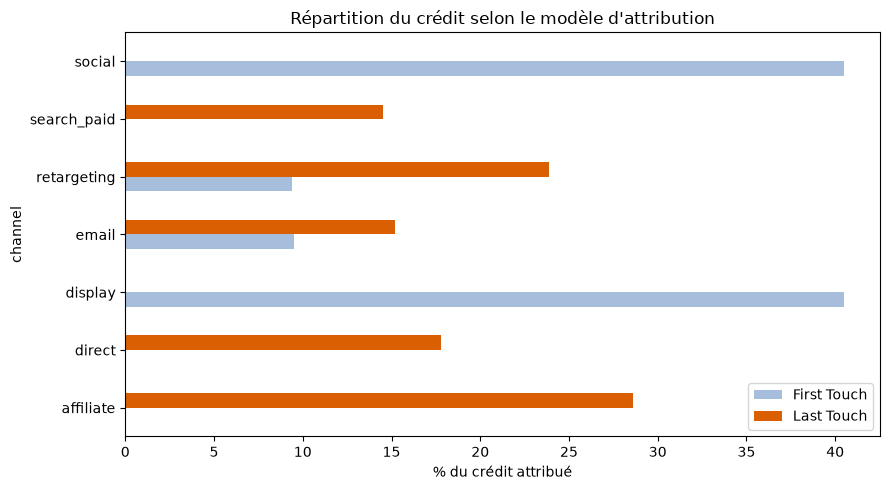

In [27]:
comparison_attribution = pd.DataFrame({
    "First Touch": first_touch_credit,
    "Last Touch": last_touch_credit
}).fillna(0)

comparison_attribution.plot(kind="barh", figsize=(9,5), color=["#a6bddb", "#d95f02"])
plt.xlabel("% du crédit attribué")
plt.title("Répartition du crédit selon le modèle d'attribution")
plt.tight_layout()
plt.show()

In [29]:
print(touchpoints["channel"].unique())  # pour vérifier le nom exact avant de filtrer

<StringArray>
[      'email',   'affiliate', 'retargeting',      'social',     'display',
      'direct', 'search_paid']
Length: 7, dtype: str


In [32]:
display_name = "display"  
display_first = first_touch_credit.get(display_name, 0)
display_last = last_touch_credit.get(display_name, 0)
print(f"Display en première position : {display_first}%")
print(f"Display en dernière position : {display_last}%")

Display en première position : 40.5%
Display en dernière position : 0%


In [33]:
primary_channels_list = campaigns["primary_channel"].unique()
kpi_summary.loc[kpi_summary.index.isin(primary_channels_list)]

,CAC,CPA,ROAS,Taux_conversion_%,rang_CAC,rang_ROAS,rang_conversion
channel,,,,,,,
display,NaN,NaN,NaN,0.0,NaN,NaN,6.5
social,NaN,NaN,NaN,0.0,NaN,NaN,6.5


## Résumé TP3 — KPIs & Attribution

**KPIs par canal (Étape 1)** :
- 5 canaux mesurables directement (CAC/CPA/ROAS) : direct, retargeting, email, search_paid, affiliate
- 2 canaux invisibles sur ces métriques : display et social — 0% de conversion directe, 
  CAC/ROAS non calculables (NaN), alors qu'ils représentent à eux deux plus de la moitié 
  du volume total de touchpoints (316 530 + 315 763 sur 1 080 897, soit ~58%)

**Attribution (Étape 2)** :
- 5 touchpoints en moyenne par parcours client
- Première position : Social (40,5%) et Display (40,5%) se partagent 81% des parcours — 
  aucun autre canal n'apparaît en première position
- Dernière position avant achat : Affiliate (28,6%), Retargeting (23,9%), Direct (17,8%), 
  Email (15,2%), Search paid (14,5%) — Display et Social à 0%
- primary_channel de campaigns.csv désigne "display" et "social" : les canaux déclarés 
  comme "principaux" par le CMO sont précisément ceux invisibles sur toutes les métriques 
  de performance directe